##  Module 2 | Day 3: Calculus Foundation

### 1. Functions and Rate of change 

#### 1.1 Functions in AI

Functions map inputs to outputs. In ML, functions represent models that transform input data into predictions.

House with 1500 sqft: $350,000.00


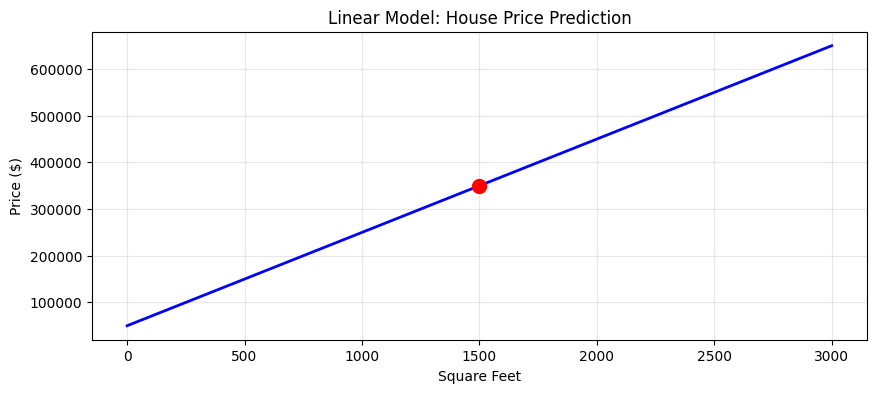

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

# Simple function: Linear model
def linear_model(x, w, b):
    """Linear function: y = wx + b"""
    return w * x + b

# Example: House price prediction
def predict_price(sqft, price_per_sqft=200, base_price=50000):
    return linear_model(sqft, price_per_sqft, base_price)

# Test the function
sqft = 1500
predicted_price = predict_price(sqft)
print(f"House with {sqft} sqft: ${predicted_price:,.2f}")

# Plot the function
x = np.linspace(0, 3000, 100)
y = predict_price(x)

plt.figure(figsize=(10, 4))
plt.plot(x, y, 'b-', linewidth=2)
plt.scatter([sqft], [predicted_price], color='red', s=100, zorder=5)
plt.xlabel('Square Feet')
plt.ylabel('Price ($)')
plt.title('Linear Model: House Price Prediction')
plt.grid(True, alpha=0.3)
plt.show()

### 1.2 Derivatives - Rate of Change

The derivative measures how a function changes as its input changes. It's the slope of the tangent line at any point.

Derivative of f(x) = x²
x	Numerical	Exact	Difference
-2	-3.999		-4.000	0.001000
-1	-1.999		-2.000	0.001000
0	0.001		0.000	0.001000
1	2.001		2.000	0.001000
2	4.001		4.000	0.001000


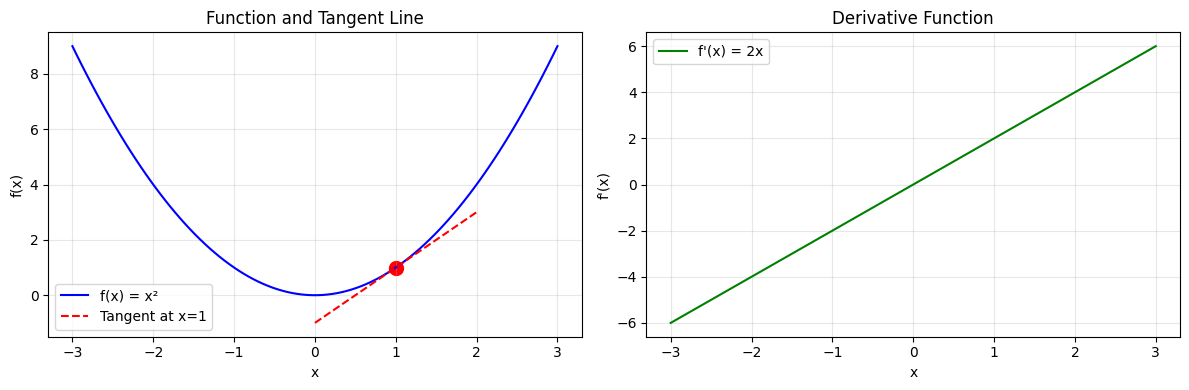


💡 ML Connection:
Derivatives tell us how to adjust parameters
to reduce prediction errors!


In [2]:

# Function: f(x) = x²
def f(x):
    return x ** 2

# Numerical derivative: (f(x+h) - f(x)) / h
def numerical_derivative(f, x, h=0.001):
    return (f(x + h) - f(x)) / h

# Exact derivative: f'(x) = 2x
def exact_derivative(x):
    return 2 * x

# Test the derivative
x_values = np.array([-2, -1, 0, 1, 2])

print("Derivative of f(x) = x²")
print("x\tNumerical\tExact\tDifference")
for x in x_values:
    num = numerical_derivative(f, x)
    exact = exact_derivative(x)
    print(f"{x:.0f}\t{num:.3f}\t\t{exact:.3f}\t{abs(num-exact):.6f}")

# Visualize derivative
x_plot = np.linspace(-3, 3, 100)
y_plot = f(x_plot)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(x_plot, y_plot, 'b-', label='f(x) = x²')
plt.scatter([1], [1], color='red', s=100)
# Tangent line at x=1
tangent_x = np.linspace(0, 2, 10)
tangent_y = 1 + 2 * (tangent_x - 1)  # f'(1) = 2
plt.plot(tangent_x, tangent_y, 'r--', label='Tangent at x=1')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Function and Tangent Line')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
derivative_values = 2 * x_plot
plt.plot(x_plot, derivative_values, 'g-', label="f'(x) = 2x")
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.title('Derivative Function')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 ML Connection:")
print("Derivatives tell us how to adjust parameters")
print("to reduce prediction errors!")

### 1.3 Partial Derivatives

Partial derivatives measure how a function changes with respect to one variable while keeping others constant.

f(2, 3) = 25
∂f/∂x at (2, 3) = 10
∂f/∂y at (2, 3) = 10


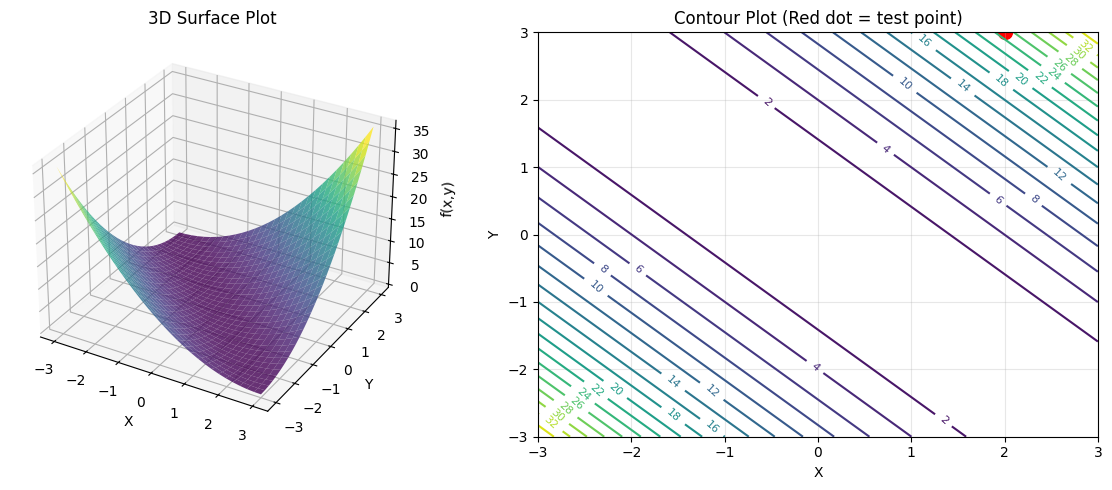


💡 ML Connection:
Partial derivatives help optimize neural networks
by adjusting individual weights!


In [3]:
# Function of two variables: f(x, y) = x² + 2xy + y²
def f_xy(x, y):
    return x**2 + 2*x*y + y**2

# Partial derivatives
def f_x(x, y):  # ∂f/∂x = 2x + 2y
    return 2*x + 2*y

def f_y(x, y):  # ∂f/∂y = 2x + 2y
    return 2*x + 2*y

# Test partial derivatives
x_test = 2
y_test = 3

print(f"f({x_test}, {y_test}) = {f_xy(x_test, y_test)}")
print(f"∂f/∂x at ({x_test}, {y_test}) = {f_x(x_test, y_test)}")
print(f"∂f/∂y at ({x_test}, {y_test}) = {f_y(x_test, y_test)}")

# Visualize 3D function
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 5))

# 3D surface plot
ax1 = fig.add_subplot(121, projection='3d')
X = np.linspace(-3, 3, 30)
Y = np.linspace(-3, 3, 30)
X, Y = np.meshgrid(X, Y)
Z = f_xy(X, Y)

ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('f(x,y)')
ax1.set_title('3D Surface Plot')

# Contour plot
ax2 = fig.add_subplot(122)
contour = ax2.contour(X, Y, Z, levels=20)
ax2.clabel(contour, inline=True, fontsize=8)
ax2.scatter([x_test], [y_test], color='red', s=100)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_title('Contour Plot (Red dot = test point)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 ML Connection:")
print("Partial derivatives help optimize neural networks")
print("by adjusting individual weights!")

### 2. Gradients & Optimization

#### 2.1 Gradient Concept

The gradient is a vector of all partial derivatives. It points in the direction of steepest ascent.

Function: f(x,y) = x² + y²
At point [2 3]:
Gradient = [4 6]
Magnitude = 7.211
Direction = Steepest ascent


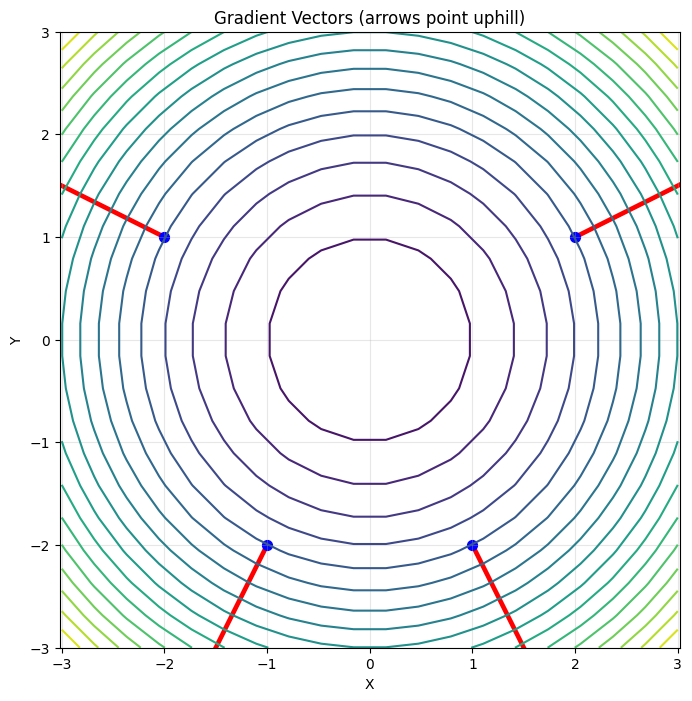


💡 ML Connection:
Gradients guide neural networks towards
minimum error by pointing uphill!


In [4]:
# Gradient of a function
def gradient_2d(x, y):
    """Gradient of f(x,y) = x² + y²"""
    return np.array([2*x, 2*y])

# Test gradient
point = np.array([2, 3])
grad = gradient_2d(point[0], point[1])

print(f"Function: f(x,y) = x² + y²")
print(f"At point {point}:")
print(f"Gradient = {grad}")
print(f"Magnitude = {np.linalg.norm(grad):.3f}")
print(f"Direction = Steepest ascent")

# Visualize gradient
fig, ax = plt.subplots(figsize=(8, 8))

# Create grid
x = np.linspace(-3, 3, 20)
y = np.linspace(-3, 3, 20)
X, Y = np.meshgrid(x, y)
Z = X**2 + Y**2

# Contour plot
ax.contour(X, Y, Z, levels=20)

# Plot gradient at several points
points = np.array([[2, 1], [-2, 1], [-1, -2], [1, -2]])
for p in points:
    grad = gradient_2d(p[0], p[1])
    ax.quiver(p[0], p[1], grad[0], grad[1], 
              color='red', angles='xy', scale_units='xy', scale=1)
    ax.scatter(p[0], p[1], color='blue', s=50)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Gradient Vectors (arrows point uphill)')
ax.grid(True, alpha=0.3)
ax.axis('equal')
plt.show()

print("\n💡 ML Connection:")
print("Gradients guide neural networks towards")
print("minimum error by pointing uphill!")

### 2.2 Gradient Descent (⭐ Core ML Algorithm)

Gradient descent is an optimization algorithm that iteratively moves towards the minimum of a function.

Starting at: [3 2]
Minimum at: [1.09684753e-04 7.31231688e-05]
Final value: 0.000000


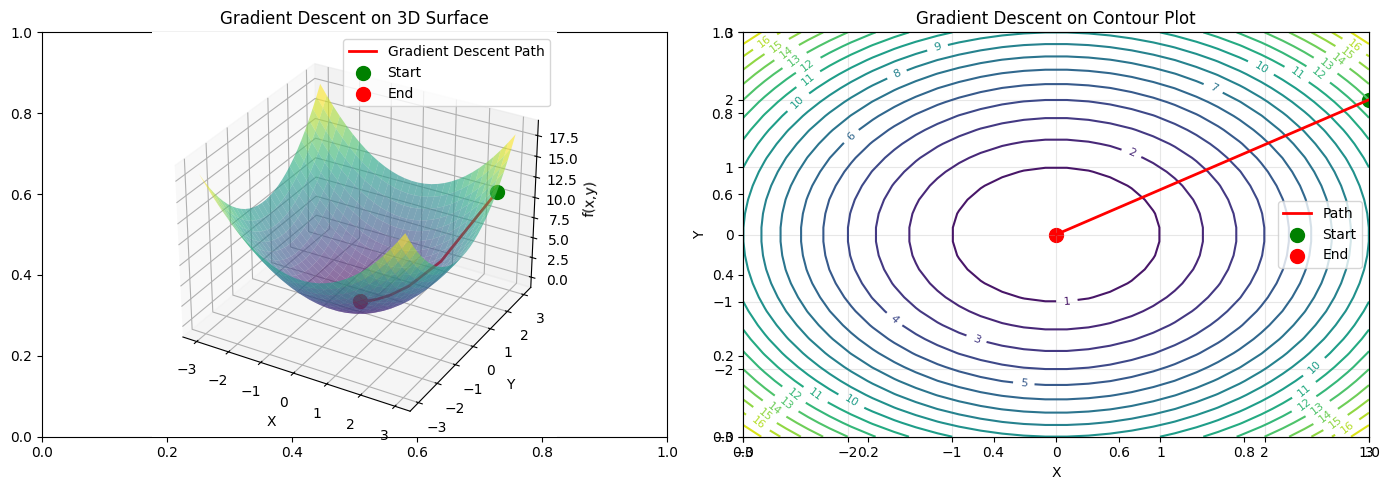


Optimization Progress:
Iteration	Position		f(x,y)
0		[3. 2.]	13.0000
5		[0.23328 0.15552]	0.0786
10		[0.01813985 0.01209324]	0.0005
15		[0.00141055 0.00094037]	0.0000
20		[1.09684753e-04 7.31231688e-05]	0.0000


In [5]:
# Gradient Descent Implementation
def gradient_descent(gradient, start, learning_rate, n_iterations):
    """
    Performs gradient descent optimization
    
    Args:
        gradient: Function that computes gradient
        start: Starting point
        learning_rate: Step size
        n_iterations: Number of iterations
    
    Returns:
        path: History of points visited
    """
    position = np.array(start)
    path = [position.copy()]
    
    for i in range(n_iterations):
        # Compute gradient at current position
        grad = gradient(position[0], position[1])
        
        # Update position (move opposite to gradient)
        position = position - learning_rate * grad
        path.append(position.copy())
    
    return np.array(path)

# Define a simple function and its gradient
def f(x, y):
    return x**2 + y**2

def grad_f(x, y):
    return np.array([2*x, 2*y])

# Run gradient descent
start = np.array([3, 2])
learning_rate = 0.2
iterations = 20

path = gradient_descent(grad_f, start, learning_rate, iterations)

print(f"Starting at: {start}")
print(f"Minimum at: {path[-1]}")
print(f"Final value: {f(path[-1][0], path[-1][1]):.6f}")

# Visualize optimization path
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 3D surface with path
ax1 = fig.add_subplot(121, projection='3d')
X = np.linspace(-3, 3, 30)
Y = np.linspace(-3, 3, 30)
X, Y = np.meshgrid(X, Y)
Z = f(X, Y)

ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6)
ax1.plot(path[:, 0], path[:, 1], f(path[:, 0], path[:, 1]), 
          'r-', linewidth=2, label='Gradient Descent Path')
ax1.scatter(path[0, 0], path[0, 1], f(path[0, 0], path[0, 1]), 
             color='green', s=100, label='Start')
ax1.scatter(path[-1, 0], path[-1, 1], f(path[-1, 0], path[-1, 1]), 
             color='red', s=100, label='End')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('f(x,y)')
ax1.set_title('Gradient Descent on 3D Surface')
ax1.legend()

# 2D contour with path
ax2 = fig.add_subplot(122)
contour = ax2.contour(X, Y, Z, levels=20)
ax2.clabel(contour, inline=True, fontsize=8)
ax2.plot(path[:, 0], path[:, 1], 'r-', linewidth=2, label='Path')
ax2.scatter(path[0, 0], path[0, 1], color='green', s=100, label='Start')
ax2.scatter(path[-1, 0], path[-1, 1], color='red', s=100, label='End')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_title('Gradient Descent on Contour Plot')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print optimization progress
print("\nOptimization Progress:")
print("Iteration\tPosition\t\tf(x,y)")
for i in range(0, len(path), 5):
    pos = path[i]
    val = f(pos[0], pos[1])
    print(f"{i}\t\t{pos}\t{val:.4f}")

### 2.3 Learning Rate Effects

Learning rate controls the step size in gradient descent. Too large: diverges. Too small: slow convergence.

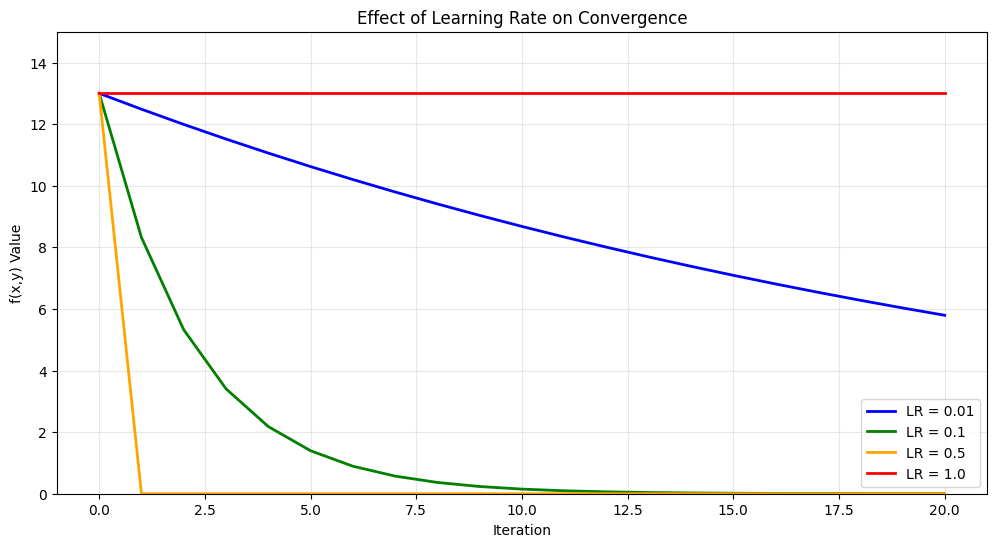


💡 ML Connection:
Learning rate is crucial for training neural networks!
Too high → Model diverges
Too low → Training is very slow
Just right → Efficient learning


In [7]:
# Compare different learning rates
def compare_learning_rates():
    learning_rates = [0.01, 0.1, 0.5, 1.0]
    colors = ['blue', 'green', 'orange', 'red']
    
    plt.figure(figsize=(12, 6))
    
    for lr, color in zip(learning_rates, colors):
        path = gradient_descent(grad_f, start, lr, 20)
        values = [f(p[0], p[1]) for p in path]
        plt.plot(range(len(values)), values, 
                color=color, label=f'LR = {lr}', linewidth=2)
    
    plt.xlabel('Iteration')
    plt.ylabel('f(x,y) Value')
    plt.title('Effect of Learning Rate on Convergence')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 15)
    plt.show()

compare_learning_rates()

print("\n💡 ML Connection:")
print("Learning rate is crucial for training neural networks!")
print("Too high → Model diverges")
print("Too low → Training is very slow")
print("Just right → Efficient learning")


### 2.4 Cost Functions in ML

Cost functions measure how well a model performs. Minimizing them is the goal of training.

Cost Functions Comparison:
MSE: 0.2252
MAE: 0.3781


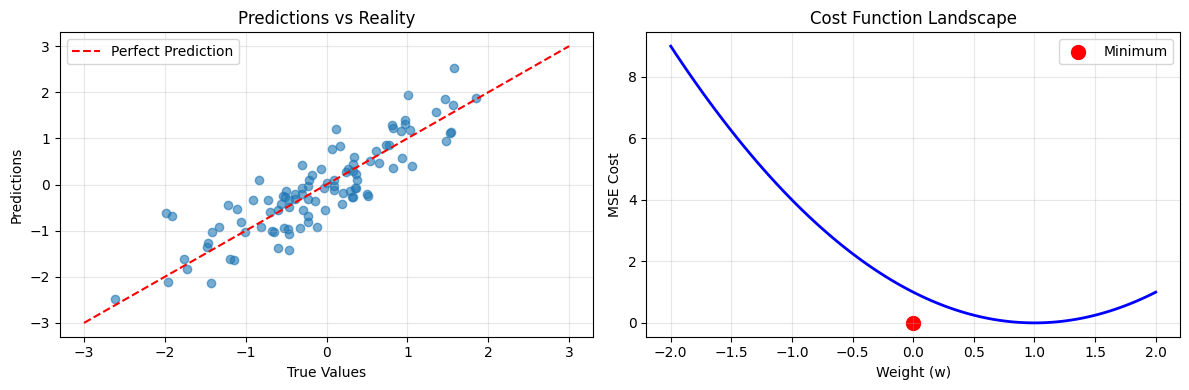


💡 ML Connection:
MSE is widely used in regression problems
Binary Cross Entropy is used in classification

📊 Binary Cross Entropy Example:
Binary Cross Entropy: 0.1643


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Common cost functions
def mean_squared_error(y_true, y_pred):
    """MSE = (1/n) * Σ(y_true - y_pred)²"""
    # Convert to numpy arrays if they aren't already
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean((y_true - y_pred) ** 2)

def mean_absolute_error(y_true, y_pred):
    """MAE = (1/n) * Σ|y_true - y_pred|"""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs(y_true - y_pred))

def binary_cross_entropy(y_true, y_pred):
    """Binary Cross Entropy"""
    epsilon = 1e-15  # Prevent log(0)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# Generate sample data
np.random.seed(42)
n_samples = 100
y_true = np.random.randn(n_samples)
noise = np.random.randn(n_samples) * 0.5
y_pred = y_true + noise  # Prediction with error

# Calculate costs
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)

print("Cost Functions Comparison:")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")

# Visualize cost function
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_true, y_pred, alpha=0.6)
plt.plot([-3, 3], [-3, 3], 'r--', label='Perfect Prediction')
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('Predictions vs Reality')
plt.legend()
plt.grid(True, alpha=0.3)

# Cost function landscape (simplified)
w = np.linspace(-2, 2, 100)
# Use scalar values instead of lists
mse_values = [mean_squared_error(1, w_i) for w_i in w]

plt.subplot(1, 2, 2)
plt.plot(w, mse_values, 'b-', linewidth=2)
plt.scatter([0], [0], color='red', s=100, label='Minimum')
plt.xlabel('Weight (w)')
plt.ylabel('MSE Cost')
plt.title('Cost Function Landscape')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 ML Connection:")
print("MSE is widely used in regression problems")
print("Binary Cross Entropy is used in classification")

# Also show binary cross entropy example
print("\n📊 Binary Cross Entropy Example:")
y_true_binary = np.array([1, 0, 1, 0])
y_pred_probs = np.array([0.9, 0.1, 0.8, 0.2])
bce = binary_cross_entropy(y_true_binary, y_pred_probs)
print(f"Binary Cross Entropy: {bce:.4f}")

### 3. Backpropagation (⭐ Core ML Algorithm)

### 3.1 Chain Rule for Derivatives

The chain rule computes derivatives of composite functions. It's the backbone of backpropagation.

In [10]:


# Chain rule demonstration
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))

# Simple neural network with chain rule
class SimpleNeuralNetwork:
    def __init__(self):
        self.w1 = 0.5
        self.w2 = 0.3
        self.b = 0.1
    
    def forward(self, x):
        # Layer 1
        z1 = self.w1 * x + self.b
        a1 = sigmoid(z1)
        
        # Layer 2 (output)
        z2 = self.w2 * a1
        a2 = sigmoid(z2)
        
        return a2, a1, z1, z2
    
    def backward(self, x, y_true):
        # Forward pass
        a2, a1, z1, z2 = self.forward(x)
        
        # Loss: MSE
        loss = (y_true - a2) ** 2
        
        # Chain rule for gradient
        dL_da2 = -2 * (y_true - a2)
        da2_dz2 = sigmoid_derivative(z2)
        dz2_dw2 = a1
        dL_dw2 = dL_da2 * da2_dz2 * dz2_dw2
        
        # For w1 (backpropagation through two layers)
        dz2_da1 = self.w2
        da1_dz1 = sigmoid_derivative(z1)
        dz1_dw1 = x
        dL_dw1 = dL_da2 * da2_dz2 * dz2_da1 * da1_dz1 * dz1_dw1
        
        return dL_dw1, dL_dw2

# Test the network
net = SimpleNeuralNetwork()
x = 1.5
y_true = 0.8

print("Simple Neural Network Backpropagation")
print(f"Input: x={x}")
print(f"Target: {y_true}")
print(f"Initial weights: w1={net.w1}, w2={net.w2}")

dL_dw1, dL_dw2 = net.backward(x, y_true)
print(f"\nGradients:")
print(f"∂L/∂w1 = {dL_dw1:.6f}")
print(f"∂L/∂w2 = {dL_dw2:.6f}")

# Update weights
learning_rate = 0.1
net.w1 -= learning_rate * dL_dw1
net.w2 -= learning_rate * dL_dw2
print(f"\nUpdated weights: w1={net.w1:.6f}, w2={net.w2:.6f}")

print("\n💡 ML Connection:")
print("Backpropagation uses chain rule to update all weights")
print("in a neural network efficiently!")

Simple Neural Network Backpropagation
Input: x=1.5
Target: 0.8
Initial weights: w1=0.5, w2=0.3

Gradients:
∂L/∂w1 = -0.011561
∂L/∂w2 = -0.085797

Updated weights: w1=0.501156, w2=0.308580

💡 ML Connection:
Backpropagation uses chain rule to update all weights
in a neural network efficiently!


### 3.2 Backpropagation Visualization

Backpropagation computes gradients backwards through the network using the chain rule.

Forward Pass:
Input: 1.5
Prediction: 0.6011

Backward Pass (Chain Rule):
Chain: ∂L/∂a2 → ∂a2/∂z2 → ∂z2/∂w2 → ∂z2/∂a1 → ∂a1/∂z1 → ∂z1/∂w1

Gradients:
∂L/∂w1 = -0.009003
∂L/∂w2 = -0.066812

Gradient Flow:


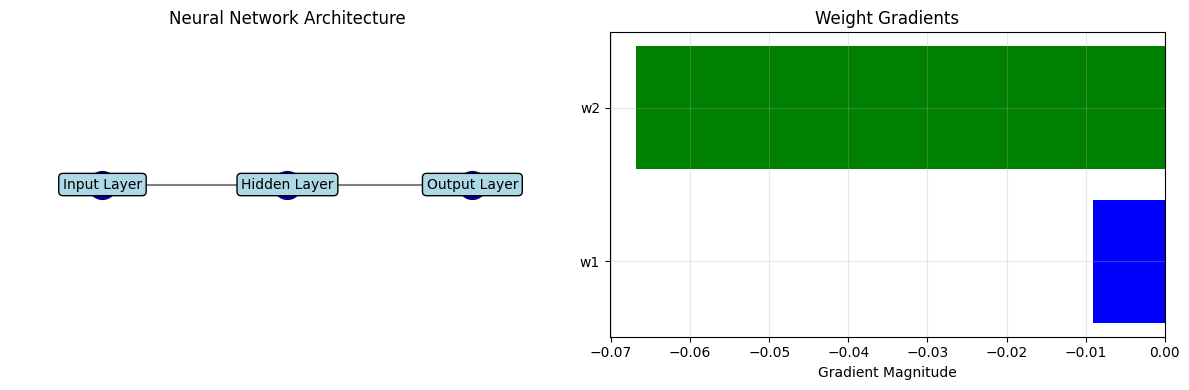


💡 ML Connection:
Backpropagation efficiently computes gradients
for all weights in a neural network!


In [11]:
# Visualize backpropagation
class BackpropVisualization:
    def __init__(self):
        self.w1 = 0.5
        self.w2 = 0.3
        self.b1 = 0.1
        self.b2 = 0.2
    
    def forward(self, x):
        # Layer 1
        self.z1 = self.w1 * x + self.b1
        self.a1 = sigmoid(self.z1)
        
        # Layer 2
        self.z2 = self.w2 * self.a1 + self.b2
        self.a2 = sigmoid(self.z2)
        
        return self.a2
    
    def backward(self, x, y_true):
        # Loss gradient
        dL_da2 = -2 * (y_true - self.a2)
        
        # Output layer
        da2_dz2 = sigmoid_derivative(self.z2)
        dz2_dw2 = self.a1
        dL_dw2 = dL_da2 * da2_dz2 * dz2_dw2
        
        # Hidden layer (backpropagation)
        dz2_da1 = self.w2
        da1_dz1 = sigmoid_derivative(self.z1)
        dz1_dw1 = x
        dL_dw1 = dL_da2 * da2_dz2 * dz2_da1 * da1_dz1 * dz1_dw1
        
        return {
            'dL_dw2': dL_dw2,
            'dL_dw1': dL_dw1,
            'gradients': [dL_dw1, dL_dw2],
            'chain': ['∂L/∂a2', '∂a2/∂z2', '∂z2/∂w2', '∂z2/∂a1', '∂a1/∂z1', '∂z1/∂w1']
        }

# Create and run
nn = BackpropVisualization()
x = 1.5
y_true = 0.8

# Forward pass
prediction = nn.forward(x)
print(f"Forward Pass:")
print(f"Input: {x}")
print(f"Prediction: {prediction:.4f}")

# Backward pass
gradients = nn.backward(x, y_true)

print(f"\nBackward Pass (Chain Rule):")
print(f"Chain: {' → '.join(gradients['chain'])}")
print(f"\nGradients:")
print(f"∂L/∂w1 = {gradients['dL_dw1']:.6f}")
print(f"∂L/∂w2 = {gradients['dL_dw2']:.6f}")

# Show gradient flow
print(f"\nGradient Flow:")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Network architecture
layer_sizes = [1, 1, 1]  # Input, hidden, output
layer_names = ['Input Layer', 'Hidden Layer', 'Output Layer']
positions = [1, 2, 3]

ax1.set_title('Neural Network Architecture')
for i, (size, name) in enumerate(zip(layer_sizes, layer_names)):
    ax1.text(positions[i], 0.5, name, ha='center', va='center',
             bbox=dict(boxstyle='round', facecolor='lightblue'))
    for j in range(size):
        ax1.plot(positions[i], 0.5 + j*0.3, 'o', 
                markersize=20, color='darkblue')
        if i > 0:
            ax1.plot([positions[i-1], positions[i]], 
                    [0.5, 0.5], 'k-', alpha=0.5)

ax1.set_xlim(0.5, 3.5)
ax1.set_ylim(0, 1)
ax1.axis('off')

# Plot 2: Gradient flow
ax2.barh(['w1', 'w2'], [gradients['dL_dw1'], gradients['dL_dw2']], 
         color=['blue', 'green'])
ax2.set_xlabel('Gradient Magnitude')
ax2.set_title('Weight Gradients')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 ML Connection:")
print("Backpropagation efficiently computes gradients")
print("for all weights in a neural network!")

### 4. Advanced Optimization Concepts 

#### 4.1 Stochastic Gradient Descent (SGD)


SGD uses random mini-batches of data to compute gradients, making training faster on large datasets.

SGD Training Progress:
Epoch	Batch	w		b		Loss
0	0	2.1178	1.0338	2.9983
0	2	2.3068	1.0880	1.2287
0	4	2.4336	1.1278	0.5476
1	0	2.4705	1.1409	0.4259
1	2	2.5246	1.1582	0.3136
1	4	2.5344	1.1664	0.2989
2	0	2.5454	1.1687	0.2890
2	2	2.5549	1.1746	0.2814
2	4	2.5620	1.1862	0.2752
3	0	2.5589	1.1895	0.2749
3	2	2.5752	1.1956	0.2723
3	4	2.5662	1.1997	0.2709
4	0	2.5774	1.2058	0.2707
4	2	2.5590	1.2030	0.2708
4	4	2.5648	1.2114	0.2681
5	0	2.5623	1.2114	0.2682
5	2	2.5527	1.2140	0.2690
5	4	2.5686	1.2240	0.2656
6	0	2.5633	1.2230	0.2654
6	2	2.5666	1.2326	0.2637
6	4	2.5651	1.2344	0.2632
7	0	2.5665	1.2358	0.2631
7	2	2.5591	1.2389	0.2618
7	4	2.5592	1.2438	0.2608
8	0	2.5537	1.2422	0.2612
8	2	2.5560	1.2492	0.2596
8	4	2.5569	1.2540	0.2586
9	0	2.5544	1.2542	0.2585
9	2	2.5598	1.2612	0.2576
9	4	2.5534	1.2635	0.2566
10	0	2.5419	1.2609	0.2584
10	2	2.5538	1.2671	0.2559
10	4	2.5560	1.2743	0.2549
11	0	2.5524	1.2765	0.2541
11	2	2.5577	1.2798	0.2544
11	4	2.5477	1.2821	0.2529
12	0	2.5490	1.2856	0.2523
12	2	2.5514	1.2898	0.2

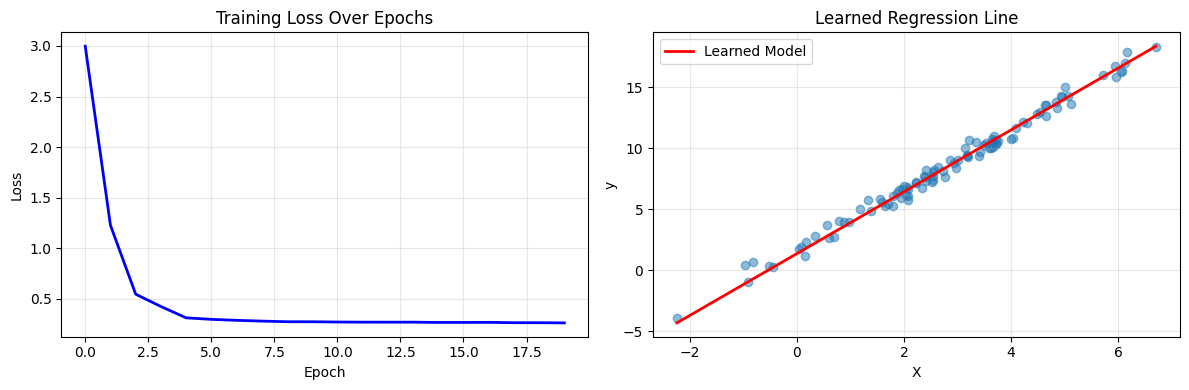


💡 ML Connection:
SGD is the workhorse of deep learning training!


In [12]:
# Compare Batch GD vs SGD
class SGDComparison:
    def __init__(self):
        self.w = 2.0
        self.b = 1.0
        
    def predict(self, X):
        return self.w * X + self.b
    
    def loss(self, X, y):
        y_pred = self.predict(X)
        return np.mean((y - y_pred) ** 2)
    
    def gradient(self, X, y):
        """Compute gradients for batch"""
        y_pred = self.predict(X)
        dw = -2 * np.mean(X * (y - y_pred))
        db = -2 * np.mean(y - y_pred)
        return dw, db
    
    def sgd_step(self, X_batch, y_batch, lr):
        """Update weights using one mini-batch"""
        dw, db = self.gradient(X_batch, y_batch)
        self.w -= lr * dw
        self.b -= lr * db
        return self.w, self.b

# Generate data
np.random.seed(42)
X = 2 * np.random.randn(100) + 3
y = 2.5 * X + 1.5 + np.random.randn(100) * 0.5

# Initialize
sgd = SGDComparison()
batch_size = 20
learning_rate = 0.01
epochs = 20

print("SGD Training Progress:")
print("Epoch\tBatch\tw\t\tb\t\tLoss")

# Training loop
losses = []
for epoch in range(epochs):
    # Shuffle data
    indices = np.random.permutation(len(X))
    X_shuffled = X[indices]
    y_shuffled = y[indices]
    
    # Mini-batches
    for i in range(0, len(X), batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        
        w, b = sgd.sgd_step(X_batch, y_batch, learning_rate)
        
        if i % 40 == 0:
            loss = sgd.loss(X, y)
            losses.append(loss)
            print(f"{epoch}\t{i//batch_size}\t{w:.4f}\t{b:.4f}\t{loss:.4f}")

print(f"\nFinal weights: w={sgd.w:.4f}, b={sgd.b:.4f}")

# Visualize convergence
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(epochs), losses[:epochs], 'b-', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(X, y, alpha=0.5)
x_line = np.linspace(min(X), max(X), 100)
y_line = sgd.predict(x_line)
plt.plot(x_line, y_line, 'r-', linewidth=2, label='Learned Model')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Learned Regression Line')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 ML Connection:")
print("SGD is the workhorse of deep learning training!")

#### 4.2 Adam Optimizer

Adam combines momentum and adaptive learning rates for faster convergence.

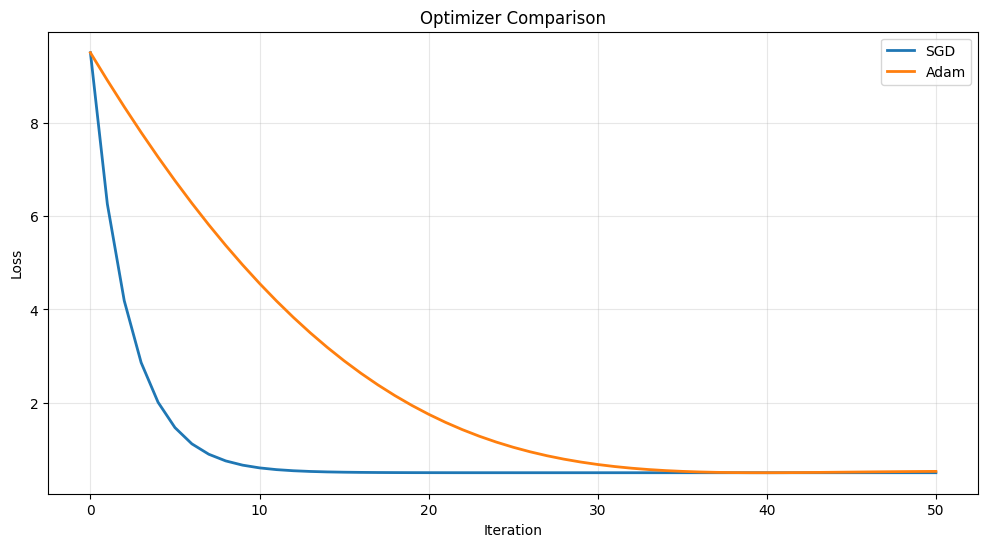


💡 ML Connection:
Adam is the most popular optimizer in deep learning
Used in GPT, BERT, and most modern AI models!


In [13]:
# Simplified Adam implementation
class AdamOptimizer:
    def __init__(self, learning_rate=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.lr = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.m = 0  # First moment
        self.v = 0  # Second moment
        self.t = 0  # Time step
    
    def update(self, gradient):
        self.t += 1
        
        # Update biased first moment estimate
        self.m = self.beta1 * self.m + (1 - self.beta1) * gradient
        
        # Update biased second moment estimate
        self.v = self.beta2 * self.v + (1 - self.beta2) * (gradient ** 2)
        
        # Bias correction
        m_hat = self.m / (1 - self.beta1 ** self.t)
        v_hat = self.v / (1 - self.beta2 ** self.t)
        
        # Update parameters
        update = -self.lr * m_hat / (np.sqrt(v_hat) + self.epsilon)
        
        return update

# Compare optimizers
def compare_optimizers():
    def loss_function(w):
        return w**2 + 0.5
    
    def gradient_function(w):
        return 2*w
    
    optimizers = {
        'SGD': {'lr': 0.1},
        'Adam': {'lr': 0.1}
    }
    
    plt.figure(figsize=(12, 6))
    
    for name, params in optimizers.items():
        w = 3.0  # Starting point
        w_history = [w]
        
        if name == 'SGD':
            for _ in range(50):
                grad = gradient_function(w)
                w = w - params['lr'] * grad
                w_history.append(w)
        else:  # Adam
            adam = AdamOptimizer(learning_rate=params['lr'])
            for _ in range(50):
                grad = gradient_function(w)
                w = w + adam.update(grad)  # update returns negative gradient
                w_history.append(w)
        
        plt.plot(range(len(w_history)), [loss_function(w) for w in w_history], 
                label=f'{name}', linewidth=2)
    
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('Optimizer Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

compare_optimizers()

print("\n💡 ML Connection:")
print("Adam is the most popular optimizer in deep learning")
print("Used in GPT, BERT, and most modern AI models!")